In [129]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score


In [130]:
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y = [0, 0, 0, 0, 1, 0, 1, 1, 1, 1]
df = pd.DataFrame({"x": x, "y" : y})

In [131]:
model = smf.logit("y~x", data=df).fit()

Optimization terminated successfully.
         Current function value: 0.250901
         Iterations 8


In [132]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                   10
Model:                          Logit   Df Residuals:                        8
Method:                           MLE   Df Model:                            1
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.6380
Time:                        17:34:05   Log-Likelihood:                -2.5090
converged:                       True   LL-Null:                       -6.9315
Covariance Type:            nonrobust   LLR p-value:                  0.002939
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -7.1590      4.759     -1.504      0.133     -16.487       2.169
x              1.3016      0.840      1.549      0.121      -0.345       2.948
==============================================================================
"""

Text(0.5, 1.0, 'Predicted Log-Odds')

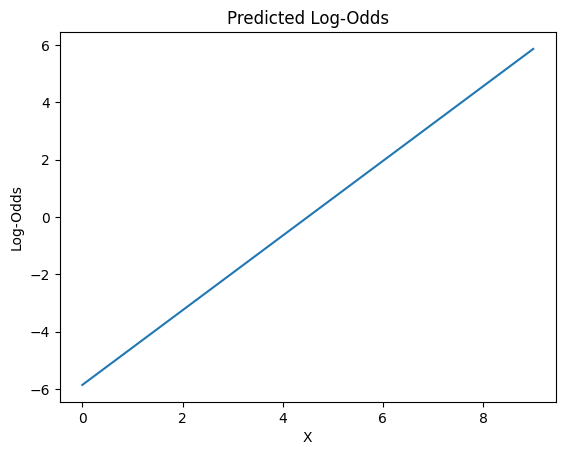

In [133]:
fitted = model.fittedvalues
plt.plot(fitted)
plt.xlabel("X")
plt.ylabel("Log-Odds")
plt.title("Predicted Log-Odds")

Text(0.5, 1.0, 'Predicted Odds')

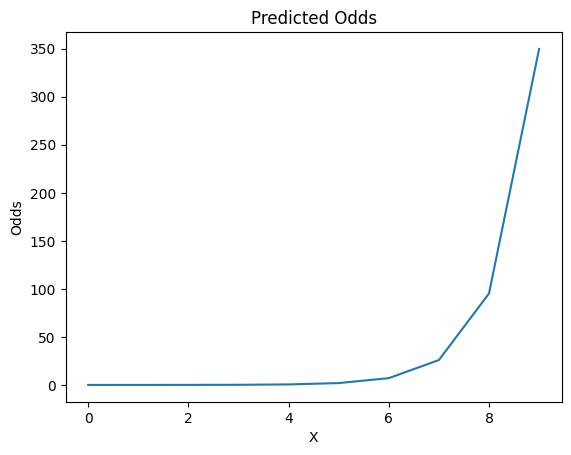

In [134]:
odds = np.exp(fitted)
plt.plot(odds)
plt.xlabel("X")
plt.ylabel("Odds")
plt.title("Predicted Odds")

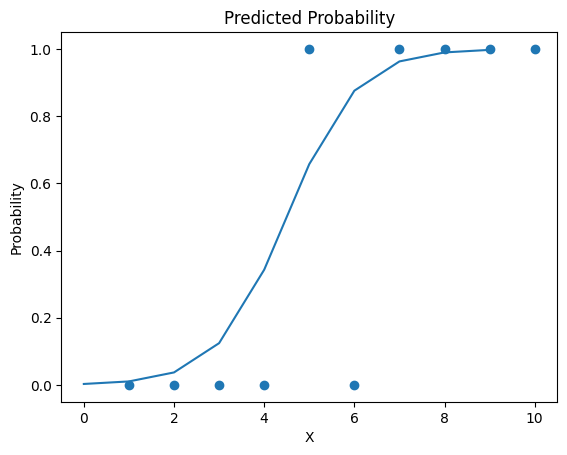

In [135]:
pred = model.predict(df)
plt.plot(pred)
plt.xlabel("X")
plt.ylabel("Probability")
plt.title("Predicted Probability")
plt.scatter(x,y)

Text(0.5, 1.0, 'Deviance Residuals vs. Predicted Log-Odds Values')

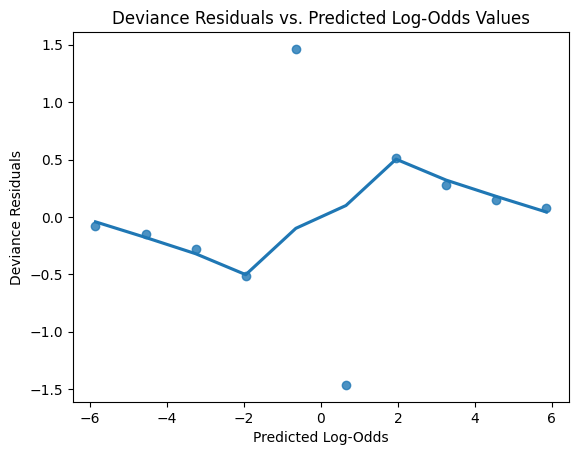

In [136]:
resid = model.resid_dev
sns.regplot(x=fitted, y=resid, lowess=True)
plt.xlabel("Predicted Log-Odds")
plt.ylabel("Deviance Residuals")
plt.title("Deviance Residuals vs. Predicted Log-Odds Values")

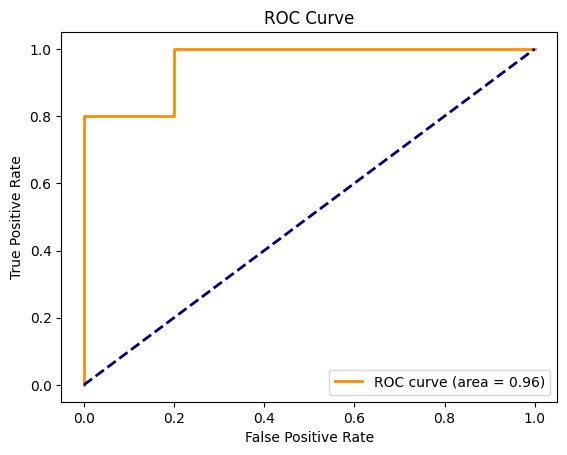

In [137]:
df["p"] = model.predict(df)
fprs, tprs, thresholds = roc_curve(y_true=df['y'], y_score=df['p'])
auc = roc_auc_score(y_true=df['y'], y_score=df['p'])
def plot_roc(fpr, tpr, auc, lw=2):
    plt.plot(fpr, tpr, color='darkorange', lw=lw,
             label='ROC curve (area = '+str(round(auc,3))+')')
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()
plot_roc(fprs, tprs, auc)


In [146]:
def logistic_reg(x, y):
    df = pd.DataFrame({"x" : x, "y" : y})
    model = smf.logit("y~x", data=df).fit()
    fitted_log = model.fittedvalues
    plt.plot(fitted_log)
    plt.xlabel("X")
    plt.grid()
    plt.ylabel("Log-Odds")
    plt.title("Predicted Log-Odds")
    log_plot = plt.show()
    odds = np.exp(fitted_log)
    plt.plot(odds)
    plt.xlabel("X")
    plt.grid()
    plt.ylabel("Odds")
    plt.title("Predicted Odds")
    odds_plot = plt.show()
    pred = model.predict(df)
    plt.plot(pred)
    plt.xlabel("X")
    plt.grid()
    plt.ylabel("Probability")
    plt.title("Predicted Probability")
    plt.scatter(x,y)
    prob_plot = plt.show()
    resid = model.resid_dev
    sns.regplot(x=fitted_log, y=resid, lowess=True)
    plt.xlabel("Predicted Log-Odds")
    plt.grid()
    plt.ylabel("Deviance Residuals")
    plt.title("Deviance Residuals vs. Predicted Log-Odds Values")
    resid_plot = plt.show()
    df["p"] = model.predict(df)
    fprs, tprs, thresholds = roc_curve(y_true=df['y'], y_score=df['p'])
    auc = roc_auc_score(y_true=df['y'], y_score=df['p'])
    plt.plot(fprs, tprs, color='darkorange', lw=2, label='ROC curve (area = '+str(round(auc,3))+')')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.grid()
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    roc_plot = plt.show()
    b0 = model.params["Intercept"]
    b1 = model.params["x"]


    
    return model.summary(), log_plot, odds_plot, prob_plot, resid_plot, roc_plot, b0, b1


Optimization terminated successfully.
         Current function value: 0.250901
         Iterations 8


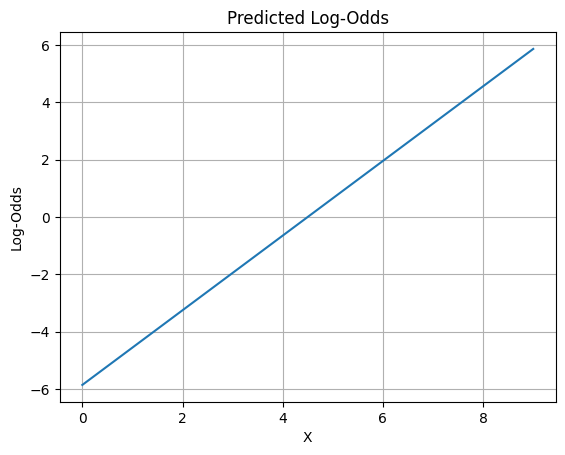

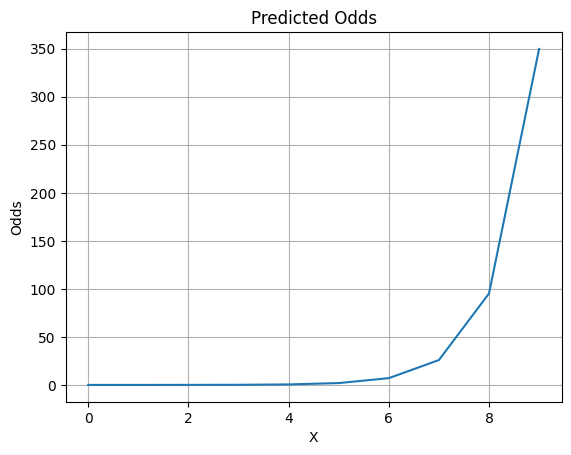

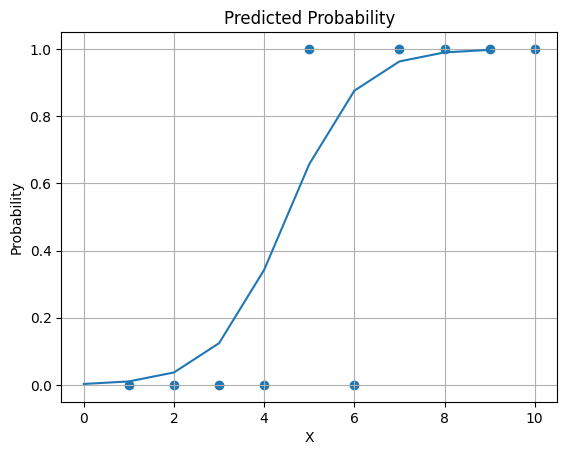

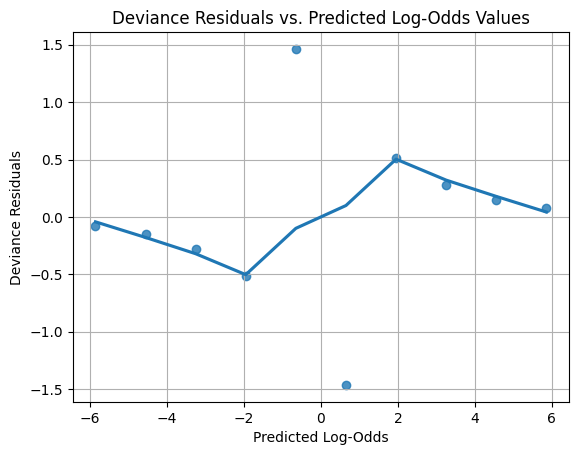

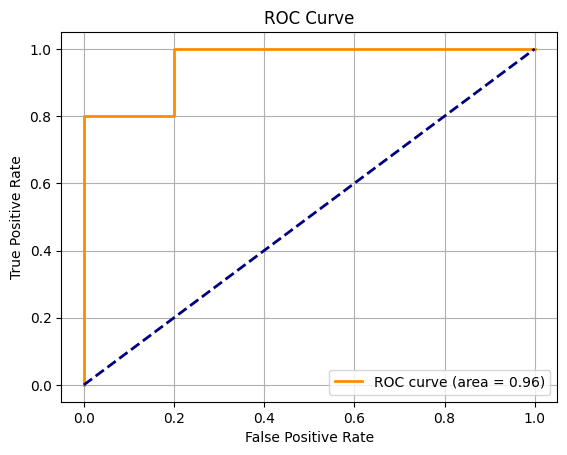

(<class 'statsmodels.iolib.summary.Summary'>
 """
                            Logit Regression Results                           
 Dep. Variable:                      y   No. Observations:                   10
 Model:                          Logit   Df Residuals:                        8
 Method:                           MLE   Df Model:                            1
 Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.6380
 Time:                        17:36:33   Log-Likelihood:                -2.5090
 converged:                       True   LL-Null:                       -6.9315
 Covariance Type:            nonrobust   LLR p-value:                  0.002939
                  coef    std err          z      P>|z|      [0.025      0.975]
 ------------------------------------------------------------------------------
 Intercept     -7.1590      4.759     -1.504      0.133     -16.487       2.169
 x              1.3016      0.840      1.549      0.121      -0.345   

In [147]:
logistic_reg(x,y)